In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [2]:
## Initialize LLM
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.7)

In [3]:
## Define State Class

class ConversationState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

def get_response(state: ConversationState):
    message = state['messages']
    
    # Generate a response using the fallback LLM
    response = llm.invoke(message)
    
    return {'messages': [response]}

### Building Graph without Memory

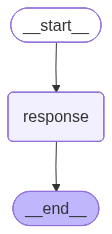

In [4]:
builder = StateGraph(ConversationState)

builder.add_node("response", get_response)

builder.add_edge(START, 'response')
builder.add_edge('response',END)

chatbot = builder.compile()

chatbot

In [5]:
while True:
    print("-- Enter quit, bye, exit & thanks to close the loop --")
    
    user_input = input()
    print('Human Message: ',user_input, end='\n')

    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break
    
    initial_state = {'messages': user_input}

    response = chatbot.invoke(initial_state)

    print(f"AI Message: {response['messages'][-1].content}")
    print("---"*30,'\n\n')

-- Enter quit, bye, exit & thanks to close the loop --
Human Message:  Hello
AI Message: Hello! How can I help you today?
------------------------------------------------------------------------------------------ 


-- Enter quit, bye, exit & thanks to close the loop --
Human Message:  I am prashant
AI Message: Nice to meet you, Prashant! How can I assist you today?
------------------------------------------------------------------------------------------ 


-- Enter quit, bye, exit & thanks to close the loop --
Human Message:  tell me what is 2 +2
AI Message: 2 + 2 = 4.
------------------------------------------------------------------------------------------ 


-- Enter quit, bye, exit & thanks to close the loop --
Human Message:  bye
Goodbye!


### Building ChatBot with Short-Term Memory

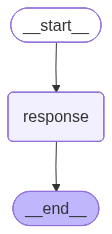

In [9]:
from langgraph.checkpoint.memory import InMemorySaver

check_pointer = InMemorySaver()

## New Graph
graph = StateGraph(ConversationState)

graph.add_node('response',get_response)

graph.add_edge(START, 'response')
graph.add_edge('response',END)

chatbot_stm = graph.compile(checkpointer=check_pointer)

chatbot_stm

In [ ]:
while True:
    print("-- Enter quit, bye, exit & thanks to close the loop --")
    
    user_input = input()
    print('Human Message: ',user_input, end='\n')

    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break
    
    initial_state = {'messages': user_input}
    config = {'configurable':{'thread_id':'abc-001'}}
    response = chatbot_stm.invoke(initial_state,config=config)

    print(f"AI Messg.get_state(config=thread).values['messages']age: {response['messages'][-1].content}")
    print("---"*30,'\n\n')

-- Enter quit, bye, exit & thanks to close the loop --
Human Message:  Hello
AI Message: Hello! How can I assist you today?
------------------------------------------------------------------------------------------ 


-- Enter quit, bye, exit & thanks to close the loop --
Human Message:  I am prashant
AI Message: Nice to meet you, Prashant! How can I help you today?
------------------------------------------------------------------------------------------ 


-- Enter quit, bye, exit & thanks to close the loop --
Human Message:  Please tell me Why cat look bit low during summer in India? Answer should be within 250 words only.
AI Message: Cats often seem “low” or lethargic during the Indian summer for several inter‑related reasons:

1. **Heat Stress** – Temperatures can soar above 35 °C (95 °F) with high humidity. Cats, like all mammals, regulate body temperature through panting, grooming, and seeking cool spots. Prolonged heat forces them to conserve energy, so they move less and may a

In [ ]:
snap = chatbot_stm.get_state(config=config)
chat_vals = snap.values

for m in chat_vals.get('messages',[]):
    print('-',type(m).__name__,':', m.content)

- HumanMessage : Hello
- AIMessage : Hello! How can I assist you today?
- HumanMessage : I am prashant
- AIMessage : Nice to meet you, Prashant! How can I help you today?
- HumanMessage : Please tell me Why cat look bit low during summer in India? Answer should be within 250 words only.
- AIMessage : Cats often seem “low” or lethargic during the Indian summer for several inter‑related reasons:

1. **Heat Stress** – Temperatures can soar above 35 °C (95 °F) with high humidity. Cats, like all mammals, regulate body temperature through panting, grooming, and seeking cool spots. Prolonged heat forces them to conserve energy, so they move less and may appear listless.

2. **Dehydration** – Hot weather increases water loss through panting and evaporative cooling. If a cat doesn’t drink enough, even mild dehydration can cause fatigue, reduced appetite, and a droopy demeanor.

3. **Reduced Activity Rhythm** – Cats are crepuscular (most active at dawn and dusk). In summer, the hottest part of t